# ACCIDENT using CLIP

## Step 0 - Import All Libraries

In [1]:
import numpy as np 
import pandas as pd 
import cv2 
import pickle
from tqdm import tqdm
from pathlib import Path
import os
import os.path as osp
import json
import gzip
import yaml
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque
from typing import Any
import torch, json, math, subprocess 
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Local paths (this device) ---
DATASET_PATH = Path("/home/andrewgirgis/Downloads/kaggle/accidents-cvpr")
SIM_DATASET_PATH = DATASET_PATH / "sim_dataset"

OPTICAL_FLOW_PATH = Path("./optical_flow.pkl")
video_paths = list((DATASET_PATH / "videos").iterdir())
metadata_df = pd.read_csv(DATASET_PATH / "test_metadata.csv", index_col="path")

# Annotations are plain .json locally (unzipped), same logic as Kaggle with gz stripped
is_kaggle = True  # reuse the is_kaggle=True path: strips .gz suffix, reads plain json

for dirname, _, filenames in os.walk(SIM_DATASET_PATH):
    for filename in filenames:
        fpath = os.path.join(dirname, filename)
        if 'video' in fpath:
            continue
        print(fpath)

Using device: cuda
/home/andrewgirgis/Downloads/kaggle/accidents-cvpr/sim_dataset/annotation_classes.yaml
/home/andrewgirgis/Downloads/kaggle/accidents-cvpr/sim_dataset/labels.csv


### Utility Functions

The annotations are stored in compressed JSON format and YAML configuration files.

In [3]:
def load_json(path: str, use_gzip: bool = True) -> Any:
    """Loads JSON/GZipped JSON annotations."""
    if use_gzip:
        with gzip.open(path, 'rt', encoding="ascii") as zipfile:
            return json.load(zipfile)
    with open(path, "r") as fp:
        return json.load(fp)


def load_yaml(path: str) -> Any:
    """Loads project configuration metadata."""
    with open(path, "r") as fp:
        return yaml.safe_load(fp)

## Step 1 - Data Inspection

Thanks to Marek Hanzl and picekl for there work!

In [4]:
sim_df = pd.read_csv(SIM_DATASET_PATH / "labels.csv")
Test_metadata = pd.read_csv(DATASET_PATH / "test_metadata.csv")
sim_df.head()

,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40
3,videos/sideswipe/Town05_sideswipe_night_30.mp4,video_annotations/Town05_sideswipe_night_30.js...,sideswipe,7.75,155,0.427604,0.600000,0.393229,0.551852,0.461979,0.648148,Town05,night,30,488,24.40,1080,1920,68
4,videos/sideswipe/Town05_sideswipe_clear_26.mp4,video_annotations/Town05_sideswipe_clear_26.js...,sideswipe,9.40,188,0.579948,0.261111,0.541146,0.195370,0.618750,0.326852,Town05,clear,26,468,23.40,1080,1920,33


## Step 1.b - Dataset Statistics

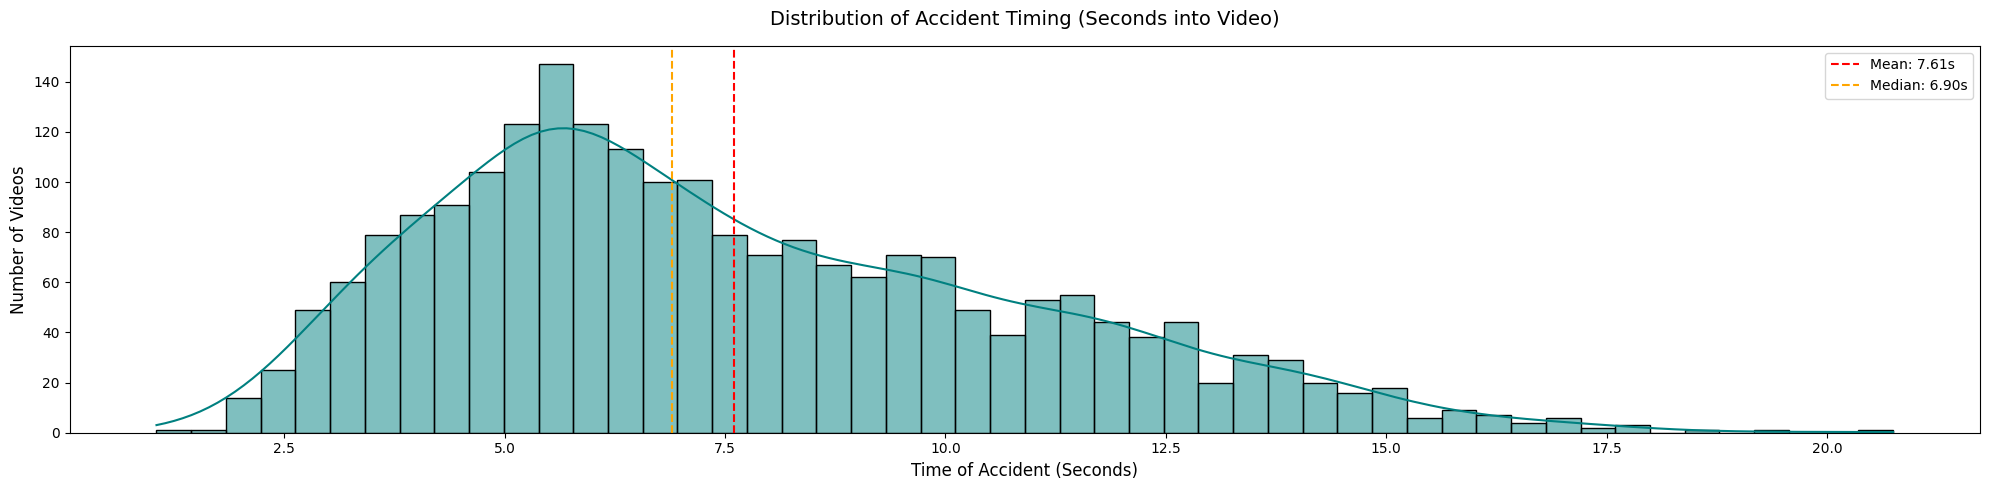

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20, 5))

sns.histplot(
    data=sim_df,
    x="accident_time",
    kde=True,
    color="teal",
    bins=50
)

ax.set_title("Distribution of Accident Timing (Seconds into Video)", fontsize=14, pad=15)
ax.set_xlabel("Time of Accident (Seconds)", fontsize=12)
ax.set_ylabel("Number of Videos", fontsize=12)

mean_time = sim_df["accident_time"].mean()
ax.axvline(mean_time, color='red', linestyle='--', label=f'Mean: {mean_time:.2f}s')

median_time = sim_df["accident_time"].median()
ax.axvline(median_time, color='orange', linestyle='--', label=f'Median: {median_time:.2f}s')
ax.legend()

plt.tight_layout()
plt.show()


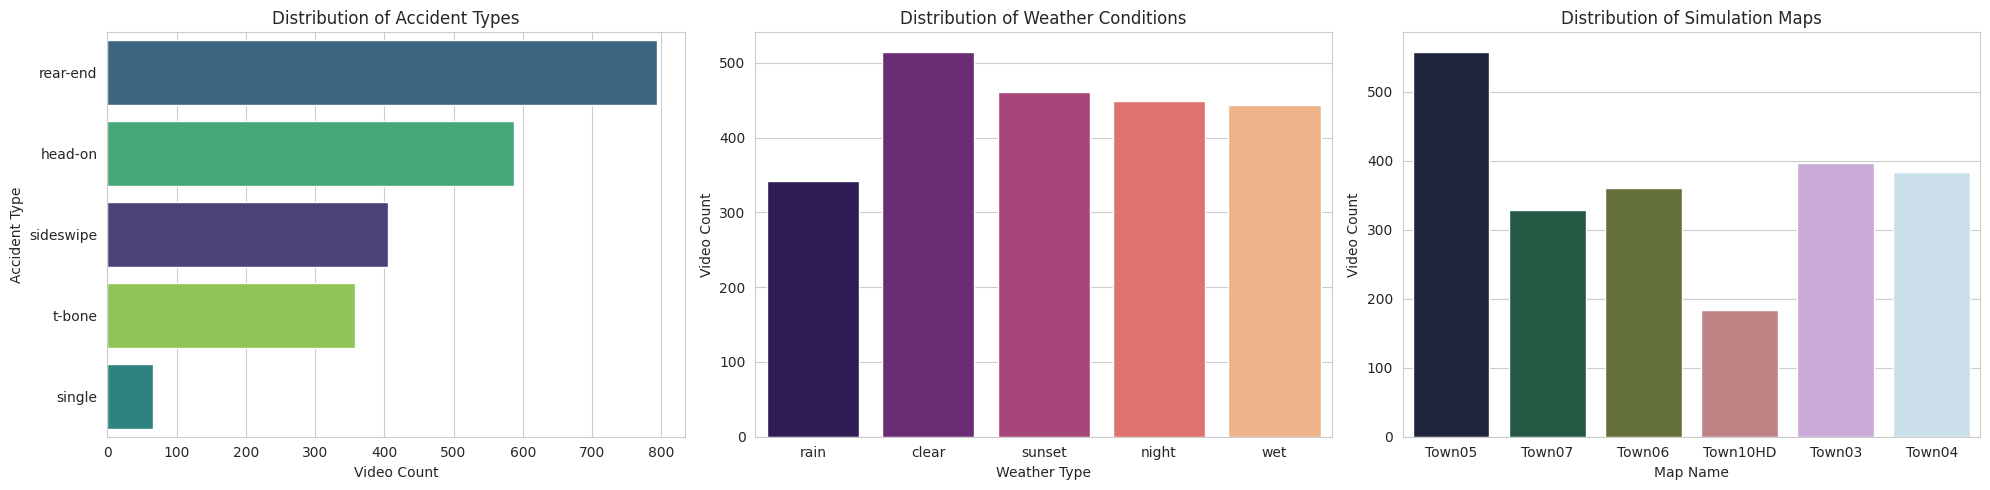

In [6]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(y="type", hue="type", data=sim_df, ax=axes[0], order=sim_df['type'].value_counts().index, palette="viridis", legend=False)
axes[0].set_title("Distribution of Accident Types")
axes[0].set_xlabel("Video Count")
axes[0].set_ylabel("Accident Type")


sns.countplot(x="weather", hue="weather", data=sim_df, ax=axes[1], palette="magma", legend=False)
axes[1].set_title("Distribution of Weather Conditions")
axes[1].set_xlabel("Weather Type")
axes[1].set_ylabel("Video Count")

sns.countplot(x="map", hue="map", data=sim_df, ax=axes[2], palette="cubehelix", legend=False)
axes[2].set_title("Distribution of Simulation Maps")
axes[2].set_xlabel("Map Name")
axes[2].set_ylabel("Video Count")

plt.tight_layout()
plt.show()


## Step 1.c - Annotation Parsing

In [7]:
# Select a random sample for visualization
sample_index = random.randint(0, len(sim_df) - 1)
sample = sim_df.iloc[sample_index]

video_path = str(SIM_DATASET_PATH / sample["rgb_path"])

# Local annotation structure: labels.csv lists .json.gz paths, but locally each
# annotation is a directory named <stem>.json containing a file of the same name.
# e.g. video_annotations/Town05_sideswipe_rain_44.json/Town05_sideswipe_rain_44.json
ann_dir = SIM_DATASET_PATH / Path(sample["annotations_path"]).with_suffix("")  # strip .gz
annotations_path = str(ann_dir / ann_dir.name)  # <dir>/<same-name>.json

print(f"Video path:      {video_path}")
print(f"Annotation path: {annotations_path}")

# Files are plain .json locally
annotations = load_json(annotations_path, use_gzip=False)
base = annotations["base"]           # Frame object detections
collision = annotations["collision"] # Collision event
sensor = annotations["sensor"]       # Camera sensor placement

annotations_offset = sample["annotations_start_offset"]

Video path:      /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/sim_dataset/videos/rear-end/Town07_rear-end_clear_58.mp4
Annotation path: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/sim_dataset/video_annotations/Town07_rear-end_clear_58.json/Town07_rear-end_clear_58.json


## Step 2 - Create the CLIP model for one-shot

In [8]:
import torch, torch.nn.functional as F
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# Competition collision types → mapped to descriptive prompts
COLLISION_TYPES = ["head-on", "rear-end", "sideswipe", "t-bone", "single"]
COLLISION_PROMPTS = [
    "a head-on collision between two vehicles",
    "a rear-end collision where one car hits another from behind",
    "a sideswipe collision where two vehicles scrape along each other",
    "a t-bone collision where one vehicle crashes into the side of another",
    "a single-vehicle accident with no other cars involved",
]

# GDINO vehicle prompt — period-separated as required by the model
GDINO_VEHICLE_TEXT = "car . truck . bus . motorcycle . vehicle ."

class ZeroShotAccidentDetector:
    def __init__(self, device="cuda"):
        self.device = device

        # --- CLIP ---
        self.model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.temp_prompt = ["a car accident happening"]
        self.spat_prompt = ["the point of impact between vehicles"]
        self.collision_types = COLLISION_TYPES
        self.collision_prompts = COLLISION_PROMPTS
        self.collision_tokens = self.processor(
            text=self.collision_prompts, return_tensors="pt", padding=True
        ).to(device)

        # --- Grounding DINO tiny ---
        _gdino_id = "IDEA-Research/grounding-dino-tiny"
        print(f"Loading Grounding DINO ({_gdino_id}) ...")
        self.gdino_processor = AutoProcessor.from_pretrained(_gdino_id)
        self.gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(_gdino_id).to(device)
        self.gdino_model.eval()
        print("Grounding DINO loaded.")

    def encode_video(self, video_path, fps=2):
        """Return frame embeddings (T x D) and timestamps (seconds)."""
        cap = cv2.VideoCapture(video_path)
        native_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        frame_interval = max(1, int(round(native_fps / fps)))

        frame_embeds = []
        timestamps = []
        frame_idx = 0

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx % frame_interval == 0:
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                inputs = self.processor(images=rgb, return_tensors="pt")
                pixel_values = inputs["pixel_values"].to(self.device)
                with torch.no_grad():
                    vision_out = self.model.vision_model(pixel_values=pixel_values)
                    embed = self.model.visual_projection(vision_out.pooler_output)
                    embed = F.normalize(embed, dim=-1)
                frame_embeds.append(embed.squeeze(0))
                timestamps.append(frame_idx / native_fps)
            frame_idx += 1

        cap.release()
        if not frame_embeds:
            raise ValueError(f"No frames extracted from {video_path}")
        return torch.stack(frame_embeds), timestamps

    def localize_impact(self, video_path, peak_time, window_sec=2.0,
                        threshold=0.3, text_threshold=0.25, sample_fps=2.0):
        """
        Run Grounding DINO on frames in [peak_time ± window_sec].
        Finds the closest vehicle pair in each frame; returns the normalized
        (cx, cy) midpoint from the frame where vehicles are nearest
        (i.e. most likely at the moment of collision).

        Falls back to (0.5, 0.5) if fewer than 2 vehicles are detected
        in any sampled frame.
        """
        cap = cv2.VideoCapture(video_path)
        native_fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        start_frame = max(0, int((peak_time - window_sec) * native_fps))
        end_frame   = min(total_frames - 1, int((peak_time + window_sec) * native_fps))
        frame_step  = max(1, int(native_fps / sample_fps))
        target_frames = list(range(start_frame, end_frame + 1, frame_step))

        best_cx, best_cy = 0.5, 0.5
        best_min_dist = float("inf")

        for fidx in target_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
            ret, frame = cap.read()
            if not ret:
                continue

            h, w = frame.shape[:2]
            pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            inputs = self.gdino_processor(
                images=pil_img,
                text=GDINO_VEHICLE_TEXT,
                return_tensors="pt",
            ).to(self.device)

            with torch.no_grad():
                outputs = self.gdino_model(**inputs)

            # transformers 5.x: 'threshold' controls box score; 'text_threshold' controls label score
            results = self.gdino_processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                threshold=threshold,
                text_threshold=text_threshold,
                target_sizes=[(h, w)],
            )[0]

            boxes = results["boxes"].cpu().numpy()  # (N, 4) xyxy pixels
            if len(boxes) < 2:
                continue

            # Normalised box centres
            centres = np.column_stack([
                (boxes[:, 0] + boxes[:, 2]) / 2 / w,
                (boxes[:, 1] + boxes[:, 3]) / 2 / h,
            ])

            # Find the closest pair — that's the colliding pair
            n = len(centres)
            for i in range(n):
                for j in range(i + 1, n):
                    d = float(np.linalg.norm(centres[i] - centres[j]))
                    if d < best_min_dist:
                        best_min_dist = d
                        best_cx = float((centres[i, 0] + centres[j, 0]) / 2)
                        best_cy = float((centres[i, 1] + centres[j, 1]) / 2)

        cap.release()
        return best_cx, best_cy

In [9]:
from scipy.ndimage import gaussian_filter1d

def predict_clip(detector, video_path):
    """Run zero-shot accident prediction on a single video."""
    # 1. Encode frames
    frame_embeds, timestamps = detector.encode_video(video_path, fps=2)

    # 2. Text embeddings
    with torch.no_grad():
        _tinputs = detector.processor(text=detector.temp_prompt, return_tensors="pt", padding=True).to(detector.device)
        temp_embed = detector.model.text_projection(detector.model.text_model(**_tinputs).pooler_output)
        coll_embed = detector.model.text_projection(detector.model.text_model(**detector.collision_tokens).pooler_output)
        temp_embed = F.normalize(temp_embed, dim=-1)
        coll_embed = F.normalize(coll_embed, dim=-1)

    # 3. Temporal similarity scores
    temp_scores = (frame_embeds @ temp_embed.T).squeeze(1).cpu().numpy()

    # 4. Find temporal peak via Gaussian smoothing
    temp_smooth = gaussian_filter1d(temp_scores, sigma=1.0)
    peak_idx = int(np.argmax(temp_smooth))
    pred_time = timestamps[peak_idx]

    # 5. Spatial localisation via Grounding DINO
    #    Run GDINO on a ±2s window around the CLIP peak; find closest vehicle pair.
    x_norm, y_norm = detector.localize_impact(video_path, peak_time=pred_time, window_sec=2.0)

    # 6. Collision type: average CLIP scores in a ±0.5s window around peak
    half_win = max(1, int(0.5 * 2))  # 0.5 sec * fps
    start = max(0, peak_idx - half_win)
    end = min(len(frame_embeds), peak_idx + half_win + 1)
    coll_scores = (frame_embeds @ coll_embed.T)[start:end].mean(dim=0)
    pred_coll_idx = int(coll_scores.argmax().item())
    pred_type = detector.collision_types[pred_coll_idx]

    return {
        "accident_time": pred_time,
        "center_x": x_norm,
        "center_y": y_norm,
        "type": pred_type,
    }

## Step 3 - Sample Inference on Real Test Videos

In [10]:
import random

# Instantiate detector
detector = ZeroShotAccidentDetector(device=str(device))

# Sample N random test videos
SAMPLE_N = 5
all_test_videos = sorted((DATASET_PATH / "videos").iterdir())
sample_videos = random.sample(all_test_videos, min(SAMPLE_N, len(all_test_videos)))

results = []
for vpath in sample_videos:
    print(f"\nProcessing: {vpath.name}")
    pred = predict_clip(detector, str(vpath))
    pred["path"] = vpath.name
    results.append(pred)
    print(f"  accident_time : {pred['accident_time']:.2f}s")
    print(f"  center        : ({pred['center_x']:.3f}, {pred['center_y']:.3f})")
    print(f"  type          : {pred['type']}")

results_df = pd.DataFrame(results)[["path", "accident_time", "center_x", "center_y", "type"]]
display(results_df)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Grounding DINO (IDEA-Research/grounding-dino-tiny) ...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Grounding DINO loaded.

Processing: jbfxAh30dDc_00.mp4
  accident_time : 0.00s
  center        : (0.694, 0.278)
  type          : rear-end

Processing: BGxp7NOV0AQ_00.mp4
  accident_time : 3.02s
  center        : (0.536, 0.665)
  type          : single

Processing: KUBbn-T3XYI_00.mp4
  accident_time : 10.66s
  center        : (0.290, 0.095)
  type          : rear-end

Processing: _-XReeuhpiE_00.mp4
  accident_time : 3.62s
  center        : (0.977, 0.196)
  type          : head-on

Processing: zxu3S-7VZUA_00.mp4
  accident_time : 2.34s
  center        : (0.204, 0.204)
  type          : single


,path,accident_time,center_x,center_y,type
0,jbfxAh30dDc_00.mp4,0.000000,0.693622,0.277672,rear-end
1,BGxp7NOV0AQ_00.mp4,3.024639,0.536059,0.665018,single
2,KUBbn-T3XYI_00.mp4,10.662252,0.289917,0.094809,rear-end
3,_-XReeuhpiE_00.mp4,3.620690,0.976889,0.195973,head-on
4,zxu3S-7VZUA_00.mp4,2.336574,0.204219,0.203760,single


## Step 4 - Full Test Set Inference & Submission

In [11]:
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SUBMISSIONS_DIR = DATASET_PATH / 'submissions'
SUBMISSIONS_DIR.mkdir(exist_ok=True)
SUBMISSION_PATH = SUBMISSIONS_DIR / 'clip_zero_shot.csv'

# Load test metadata — use its path column as the canonical submission key
test_meta = pd.read_csv(DATASET_PATH / 'test_metadata.csv')
# test_meta['path'] is like 'videos/abc123_00.mp4'
test_video_paths = [(DATASET_PATH / row['path'], row['path']) for _, row in test_meta.iterrows()]

# Instantiate detector (reuse if already in memory)
if 'detector' not in dir():
    detector = ZeroShotAccidentDetector(device=str(device))

results = []
failed = []

for vpath, rel_path in tqdm(test_video_paths, desc='Inference'):
    try:
        pred = predict_clip(detector, str(vpath))
        results.append({
            'path': rel_path,
            'accident_time': pred['accident_time'],
            'center_x': pred['center_x'],
            'center_y': pred['center_y'],
            'type': pred['type'],
        })
    except Exception as e:
        print(f'\nFailed: {rel_path} — {e}')
        failed.append(rel_path)
        # Fill with safe defaults so every test video appears in submission
        results.append({
            'path': rel_path,
            'accident_time': 10.0,
            'center_x': 0.5,
            'center_y': 0.5,
            'type': 'rear-end',
        })

submission_df = pd.DataFrame(results)[['path', 'accident_time', 'center_x', 'center_y', 'type']]
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f'\nDone. {len(results)} videos processed, {len(failed)} failed.')
print(f'Saved to: {SUBMISSION_PATH}')
print(f'\nType distribution:')
print(submission_df['type'].value_counts().to_string())
submission_df.head(10)


Inference: 100%|██████████| 2027/2027 [1:42:22<00:00,  3.03s/it]


Done. 2027 videos processed, 0 failed.
Saved to: /home/andrewgirgis/Downloads/kaggle/accidents-cvpr/submissions/clip_zero_shot.csv

Type distribution:
type
single       984
rear-end     745
t-bone       159
head-on      125
sideswipe     14


,path,accident_time,center_x,center_y,type
0,videos/Z4kg2Ev3vhk_00.mp4,1.976471,0.500000,0.500000,single
1,videos/unS0-TLF1ao_00.mp4,1.920000,0.390793,0.121726,single
2,videos/UarP8qU1S-c_00.mp4,10.998057,0.648209,0.240294,t-bone
3,videos/UarP8qU1S-c_01.mp4,3.753405,0.608382,0.400571,t-bone
4,videos/nAXTthLfgtI_00.mp4,1.598086,0.500000,0.500000,t-bone
5,videos/fzWY0vLAXzI_00.mp4,6.759083,0.889186,0.228234,rear-end
6,videos/vxZ47DoPNY8_00.mp4,4.545324,0.324146,0.192714,rear-end
7,videos/OXVXsdDT9QQ_00.mp4,5.273408,0.298655,0.162703,head-on
8,videos/VozrseCzhQc_00.mp4,8.496552,0.492665,0.608366,single
9,videos/kABWTDKgc9U_00.mp4,25.028153,0.777810,0.287743,rear-end
